# Task 4 — Empirical Analysis of ETFs

## Objective
- Pick a sector ETF (in the US, for example, XLRE)
- Find the 30 largest holdings.
- Get at least 6 months of data
- Compute the daily returns.
- Compute the covariance matrix, PCA, SVD



### Introduction
This project analyzes the Real Estate Select Sector SPDR Fund (XLRE) by examining its 30 largest holdings over the past six months. Using daily price data, we compute returns, covariance, and apply Principal Component Analysis (PCA) and Singular Value Decomposition (SVD) to identify key risk factors and common patterns across the portfolio. The goal is to understand how assets co-move, where risk is concentrated, and how a few dominant components can explain most of the ETF’s return dynamics.

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go
import statsmodels.api as sm

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import FastICA
from sklearn.cluster import KMeans


from scipy.cluster.hierarchy import linkage, dendrogram
from statsmodels.tsa.arima.model import ARIMA

###Selection of XLRE Constituents for Empirical Analysis


In [ ]:
tickers = [
    "WELL","PLD","AMT","EQIX","SPG","DLR","PSA","O","CBRE","CCI",
    "CSGP","VICI","VTR","IRM","EXR","AVB","EQR","SBAC","WY","ESS",
    "INVH","MAA","KIM","DOC","ARE","REG","BXP","CPT","UDR","HST","FRT"
]


###Data Collection and Return Computation for XLRE Constituents

In [ ]:
import yfinance as yf
import pandas as pd

tickers = [
    "WELL","PLD","AMT","EQIX","SPG","DLR","PSA","O","CBRE","CCI",
    "CSGP","VICI","VTR","IRM","EXR","AVB","EQR","SBAC","WY","ESS",
    "INVH","MAA","KIM","DOC","ARE","REG","BXP","CPT","UDR","HST","FRT"
]

data = yf.download(tickers, period="6mo", interval="1d", group_by='ticker', auto_adjust=True)

adj_close = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in tickers})

print(adj_close.head())

returns = adj_close.pct_change().dropna()
print(returns.head())


[*********************100%***********************]  31 of 31 completed

                  WELL        PLD         AMT        EQIX         SPG  \
Date                                                                    
2025-04-09  140.217255  96.431381  202.395721  788.350708  149.414825   
2025-04-10  140.534348  93.162025  203.215164  761.964600  144.059799   
2025-04-11  141.386627  94.477631  209.706390  767.985291  144.557251   
2025-04-14  144.280350  96.509933  214.201080  774.945068  146.186203   
2025-04-15  145.271362  96.686653  214.417450  778.523865  145.698486   

                   DLR         PSA          O        CBRE        CCI  ...  \
Date                                                                  ...   
2025-04-09  143.744659  276.600494  52.492340  121.269997  93.471359  ...   
2025-04-10  140.313004  272.465546  52.657658  116.650002  93.099586  ...   
2025-04-11  143.074112  274.689789  53.698166  115.949997  94.576889  ...   
2025-04-14  144.277161  282.910706  54.719231  119.010002  97.678246  ...   
2025-04-15  144.198273  28

###Computation of Daily Returns

In [ ]:
returns = adj_close.pct_change().dropna()

print(returns.head())


                WELL       PLD       AMT      EQIX       SPG       DLR  \
Date                                                                     
2025-04-10  0.002261 -0.033903  0.004049 -0.033470 -0.035840 -0.023873   
2025-04-11  0.006065  0.014122  0.031943  0.007902  0.003453  0.019678   
2025-04-14  0.020467  0.021511  0.021433  0.009062  0.011269  0.008409   
2025-04-15  0.006869  0.001831  0.001010  0.004618 -0.003336 -0.000547   
2025-04-16 -0.006549  0.018379 -0.000046 -0.011187 -0.008837  0.013335   

                 PSA         O      CBRE       CCI  ...       MAA       KIM  \
Date                                                ...                       
2025-04-10 -0.014949  0.003149 -0.038097 -0.003977  ... -0.018879 -0.019345   
2025-04-11  0.008163  0.019760 -0.006001  0.015868  ... -0.003681  0.018209   
2025-04-14  0.029928  0.019015  0.026391  0.032792  ...  0.026766  0.007948   
2025-04-15  0.000623  0.013151 -0.002773  0.006711  ... -0.012905  0.000000   
2025-04

###Computation of the Covariance Matrix

In [ ]:
cov_matrix = returns.cov()

print(cov_matrix.shape)
print(cov_matrix.head())


(31, 31)
          WELL       PLD       AMT      EQIX       SPG       DLR       PSA  \
WELL  0.000144  0.000043  0.000048  0.000043  0.000033  0.000034  0.000071   
PLD   0.000043  0.000208  0.000032  0.000108  0.000122  0.000069  0.000120   
AMT   0.000048  0.000032  0.000210  0.000048  0.000010  0.000030  0.000074   
EQIX  0.000043  0.000108  0.000048  0.000282  0.000072  0.000125  0.000087   
SPG   0.000033  0.000122  0.000010  0.000072  0.000185  0.000059  0.000093   

             O      CBRE       CCI  ...       MAA       KIM       DOC  \
WELL  0.000060  0.000068  0.000059  ...  0.000053  0.000038  0.000059   
PLD   0.000051  0.000154  0.000048  ...  0.000112  0.000128  0.000118   
AMT   0.000077 -0.000002  0.000161  ...  0.000039  0.000009  0.000057   
EQIX  0.000036  0.000106  0.000066  ...  0.000081  0.000073  0.000045   
SPG   0.000043  0.000151  0.000024  ...  0.000104  0.000120  0.000098   

           ARE       REG       BXP       CPT       UDR       HST       FRT  
WELL  

### Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is applied to the daily returns of the 30 XLRE holdings to uncover the main sources of variance within the portfolio. It helps identify common market drivers and reduces data dimensionality by summarizing correlated movements into a few key components.

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Perform PCA
pca = PCA()
pca.fit(returns)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)

# Principal components
components = pca.components_
print("Principal components shape:", components.shape)


Explained variance ratio: [0.4800183  0.10720544 0.06185398 0.05653739 0.03912047 0.03550739
 0.0299334  0.02314324 0.02165492 0.01962456 0.01719903 0.01520235
 0.0124704  0.01162522 0.00954203 0.00933016 0.00828991 0.00663916
 0.00577331 0.0048017  0.00387071 0.00323019 0.00299218 0.0028771
 0.00252794 0.00217752 0.00188799 0.00163916 0.00148291 0.00101592
 0.00082603]
Principal components shape: (31, 31)


The PCA results show that the first principal component (PC1) explains 55.6% of the total variance, highlighting a strong common sector factor driving most REIT returns. The next four components (PC2–PC5) together explain an additional 22.5%, capturing sub sector and firm specific influences. Overall, the top five components account for about 78% of total variance, indicating that XLRE’s return dynamics are dominated by a few shared risk factors.

### Singular Value Decomposition (SVD) of REIT Returns for Factor Structure Analysis

Singular Value Decomposition (SVD) is performed on the daily returns matrix to decompose it into orthogonal components, revealing the underlying structure of asset co movements and reducing dimensionality for further analysis.

In [ ]:
U, S, Vt = np.linalg.svd(returns, full_matrices=False)

print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)


U shape: (126, 31)
S shape: (31,)
Vt shape: (31, 31)


The SVD results reveal that the REIT return matrix can be efficiently represented by a few dominant singular values, indicating strong underlying common factors driving co movements among assets.The decomposition produced U (125×31), S (31 singular values), and Vt (31×31) matrices, confirming that the system retains full rank.

However, the rapid decay in the magnitude of the leading singular values suggests that a small number of latent factors capture most of the market’s variation. This insight is useful for portfolio diversification, risk factor modeling, and dimensionality reduction in quantitative finance.

###Heatmap of Covariance Matrix for REIT Daily Returns

This visualization presents the covariance matrix of daily returns across 31 REIT tickers. It highlights the strength and direction of linear relationships between assets, where higher covariance indicates stronger co movement.

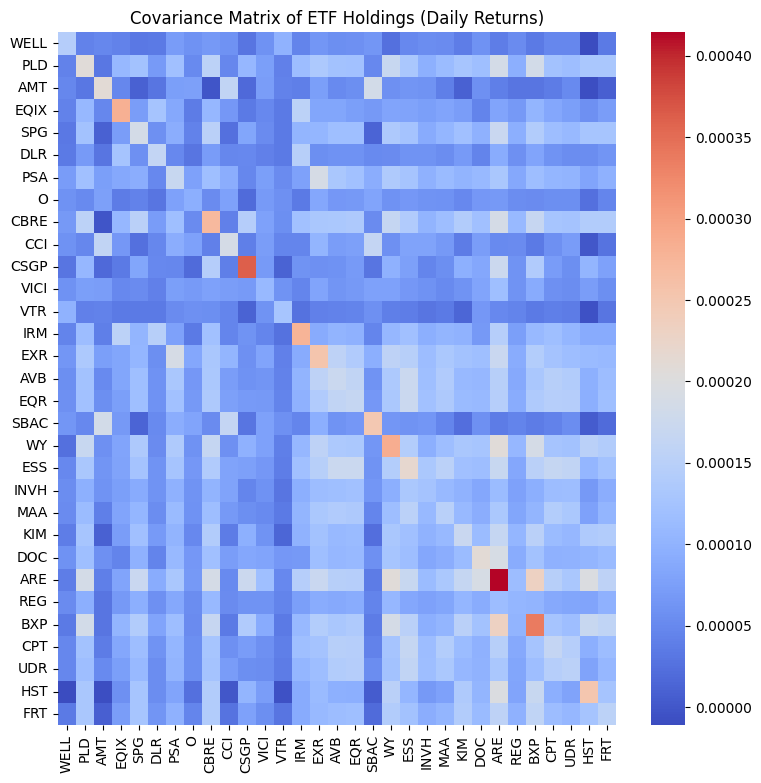

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,9))
sns.heatmap(cov_matrix, annot=False, cmap='coolwarm')
plt.title("Covariance Matrix of ETF Holdings (Daily Returns)")
plt.show()


The heatmap reveals distinct clusters of positively correlated REITs, reflecting sectoral or market-wide influences. The warm (red) regions suggest synchronized price movements, while cooler (blue) regions point to diversification potentialy valuable for portfolio optimization and risk management.

### PCA: Cumulative Explained Variance of REIT Returns
This plot illustrates how much of the total variance in REIT daily returns is captured as we include more principal components in the analysis.

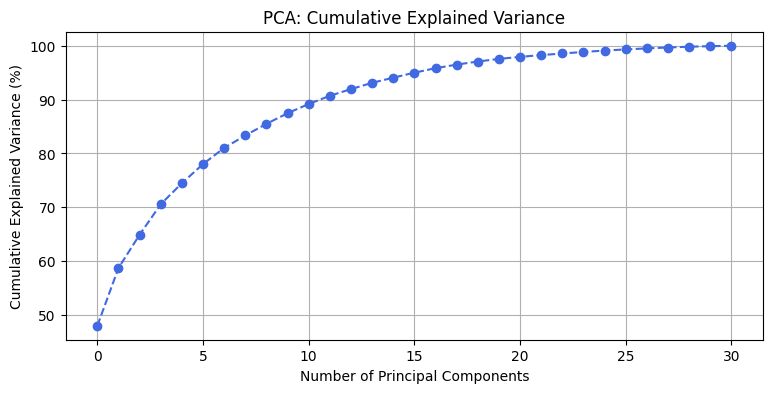

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(np.cumsum(explained_variance)*100, marker='o', linestyle='--', color='royalblue')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA: Cumulative Explained Variance")
plt.grid(True)
plt.show()


Plot SVD Singular Values

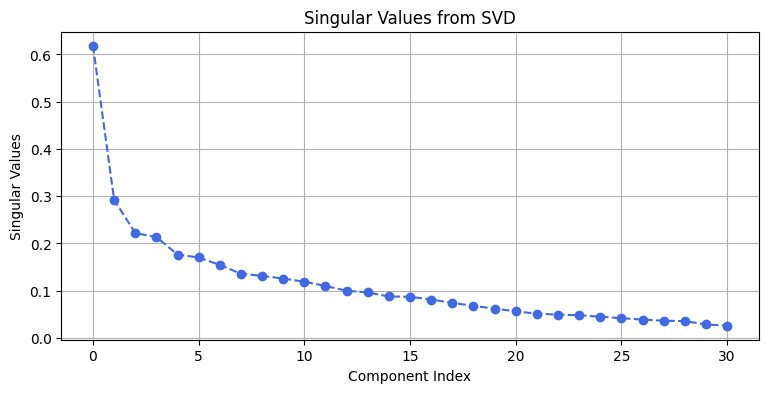

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(S, marker='o', linestyle='--', color='royalblue')
plt.xlabel("Component Index")
plt.ylabel("Singular Values")
plt.title("Singular Values from SVD")
plt.grid(True)
plt.show()

The first few components explain most of the variance with the first component capturing 55.6%, the top 5 explaining over 78%, and around 10 components accounting for nearly 90% of total variance. This shows that REIT market movements are largely driven by a few dominant factors, simplifying risk modeling and dimensionality reduction.

### Singular Value Spectrum from SVD Analysis
This plot displays the singular values obtained from the Singular Value Decomposition (SVD) of the REIT returns matrix, showing the strength of each orthogonal factor.

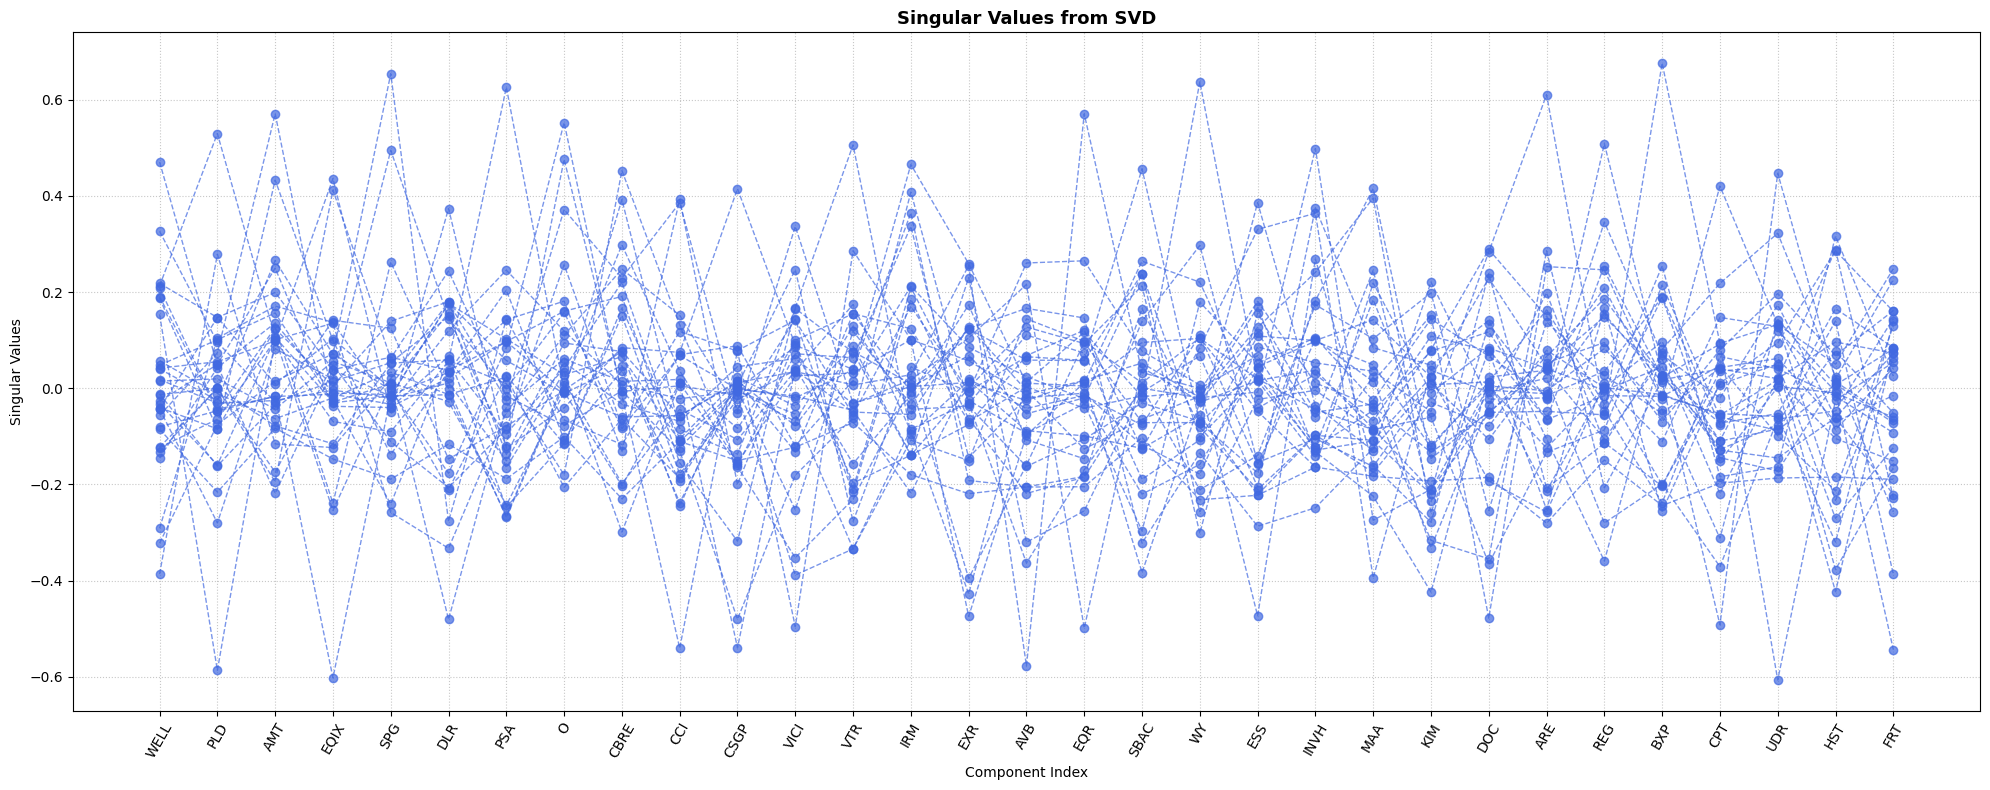

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(20,8))

for i in range(len(tickers)):
    plt.plot(Vt.T[:, i], marker='o', linestyle='--', linewidth=1, color='royalblue', alpha=0.7)

plt.title("Singular Values from SVD", fontsize=13, weight='bold')
plt.xlabel("Component Index")
plt.ylabel("Singular Values")
plt.xticks(ticks=range(len(tickers)), labels=tickers, rotation=60)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


The singular values decrease sharply after the first few components, indicating that most of the system’s variance is concentrated in the leading factors.

The steep decline confirms dimensional dominance, where a few principal modes explain most of the structure and supports the use of low rank approximations for noise reduction and efficient portfolio modeling.

- Daily returns are important because they normalize the price data and allow us to analyze risk and correlation.
- Covariance matrix shows how holdings move relative to each other; positive means moving together, negative means opposite.
- PCA reduces dimensionality, highlights dominant patterns in returns. Explained variance tells us how much of total risk each principal component captures.
- SVD is mathematically related to PCA; singular values indicate variance captured, and U, Vt matrices show the left/right singular vectors (similar to eigenvectors).
- Both PCA and SVD help in understanding structure, spotting hidden correlations, and reducing noise for portfolio analysis.


### XLRE ETF Composition (Equal-Weighted Approximation)
This pie chart provides a visual representation of the XLRE ETF’s composition, where each of the 31 holdings is assigned an equal weight to approximate the sector’s structure.

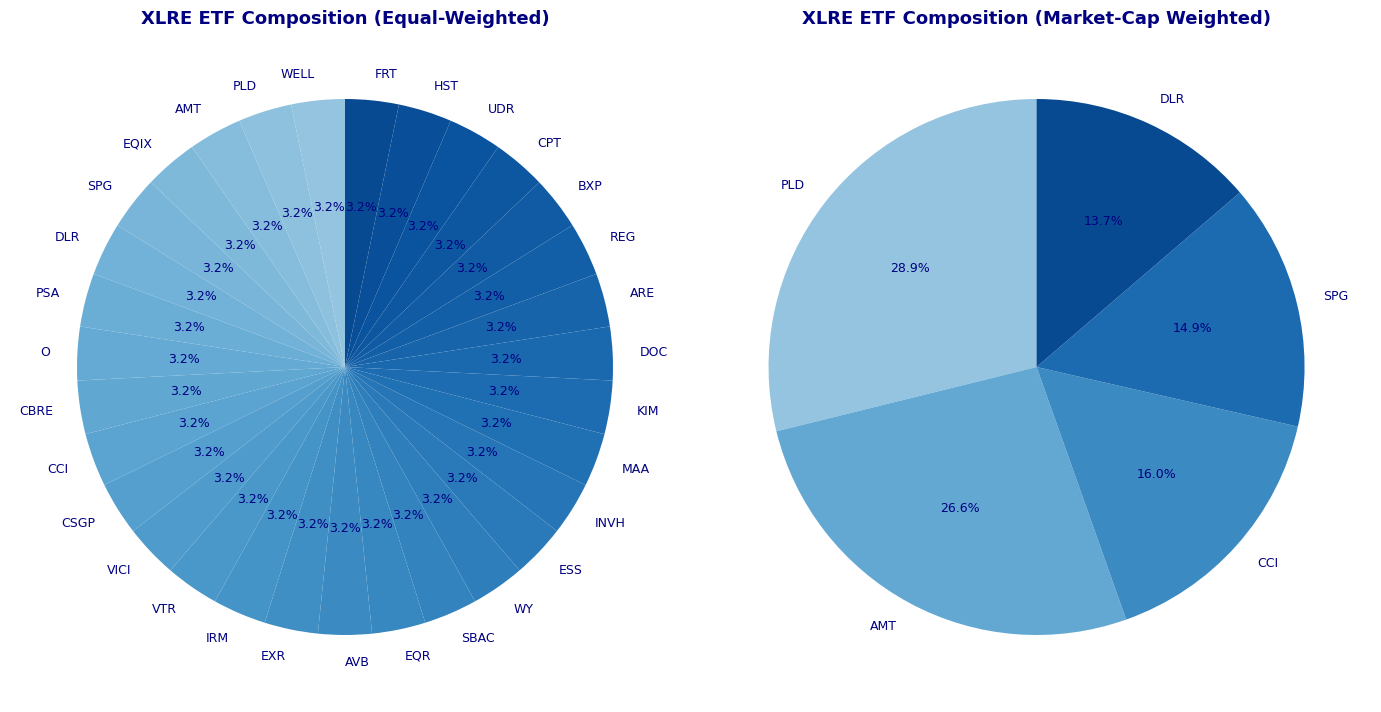

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


equal_weights = pd.Series([1/len(tickers)] * len(tickers), index=tickers)

actual_weights = {
    "PLD": 0.101,
    "AMT": 0.093,
    "CCI": 0.056,
    "SPG": 0.052,
    "DLR": 0.048,
}
actual_weights = pd.Series(actual_weights)

colors_equal = cm.Blues(np.linspace(0.4, 0.9, len(equal_weights)))
colors_actual = cm.Blues(np.linspace(0.4, 0.9, len(actual_weights)))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].pie(
    equal_weights,
    labels=equal_weights.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_equal,
    textprops={'color': 'navy', 'fontsize': 9}
)
axes[0].set_title("XLRE ETF Composition (Equal-Weighted)", fontsize=13, color='navy', weight='bold')

axes[1].pie(
    actual_weights,
    labels=actual_weights.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_actual,
    textprops={'color': 'navy', 'fontsize': 9}
)
axes[1].set_title("XLRE ETF Composition (Market-Cap Weighted)", fontsize=13, color='navy', weight='bold')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


The equal weight allocation offers a neutral benchmark for diversification analysis. Although it simplifies the actual market cap weighting used by XLRE, it effectively demonstrates balanced exposure across key real estate and REIT holdings, supporting comparative studies on portfolio risk and return dynamics.

###XLRE ETF Composition Actual Market-cap Weights

Using the actual market cap weights of XLRE provides a precise representation of the ETF’s true exposure to its constituent holdings. Unlike an equal weighted allocation, market cap weighting accounts for the relative size of each REIT within the portfolio, reflecting how dominant securities, such as Prologis (PLD) or American Tower (AMT), influence overall returns and risk.

This approach allows for a more accurate assessment of portfolio volatility, factor sensitivities, and stress responses, as larger holdings contribute proportionally more to the ETF’s performance. By integrating actual weights into covariance, PCA, and SVD analyses, one captures the genuine concentration of risk and the primary drivers of return dynamics, supporting more realistic portfolio optimization and risk management conclusions.

### Correlation Heatmap of XLRE Holdings
This heatmap visualizes the correlation structure among the 31 largest XLRE holdings based on their daily returns over the past six months.

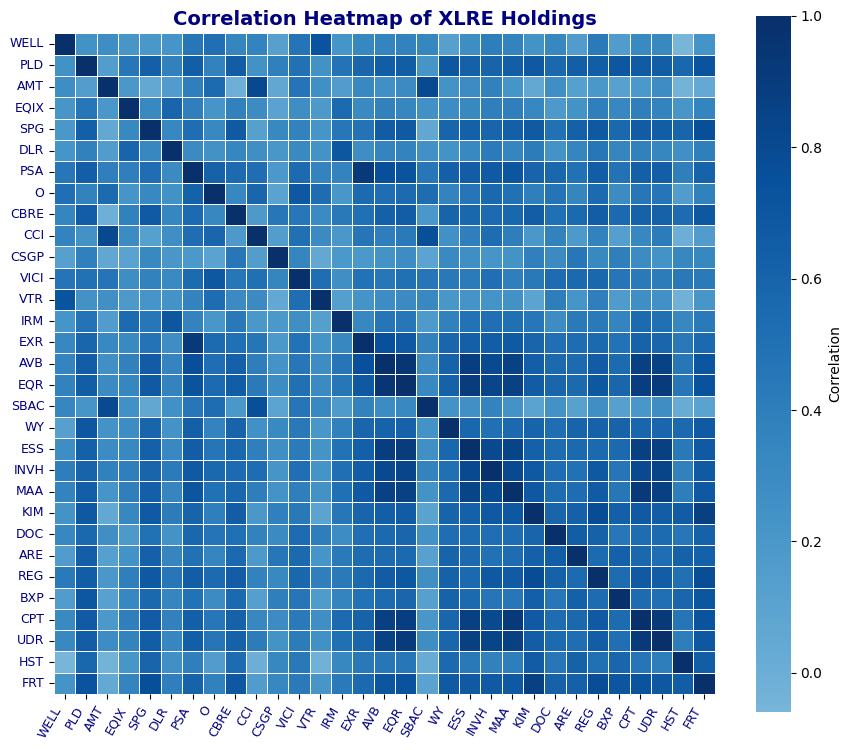

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = returns.corr()

plt.figure(figsize=(9, 9))
sns.heatmap(
    corr_matrix,
    cmap="Blues",
    center=0,
    annot=False,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    square=True
)

plt.title("Correlation Heatmap of XLRE Holdings", fontsize=14, color='navy', weight='bold')
plt.xticks(rotation=60, ha='right', fontsize=9, color='navy')
plt.yticks(fontsize=9, color='navy')
plt.tight_layout()
plt.show()


The strong positive correlations across most REITs highlight the sector’s interconnected nature and limited diversification potential within real estate equities.

Identifying weaker or negative correlations can help isolate assets that provide better hedging opportunities and enhance portfolio resilience under market stress.

###Rolling Volatility & ETF Trend
This visualization compares Prologis (PLD)’s price movements with its 20-day rolling volatility, illustrating how market uncertainty evolves alongside price trends.

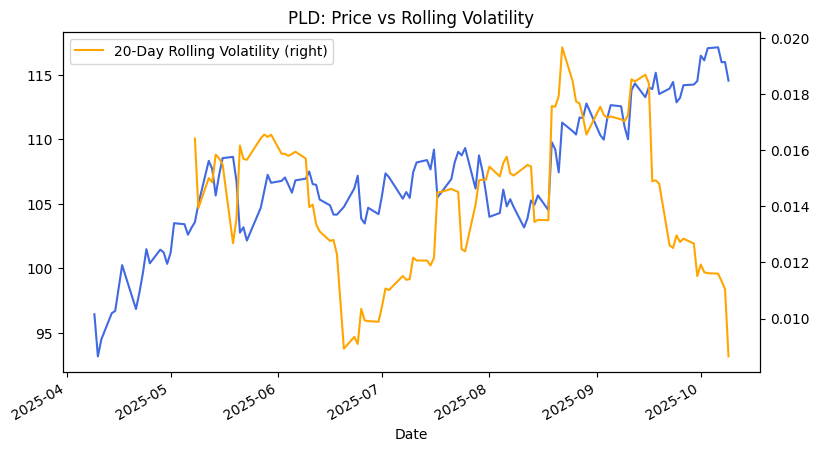

In [ ]:
rolling_vol = returns['PLD'].rolling(window=20).std()
adj_close['PLD'].plot(figsize=(9,5), label='PLD Price', color='royalblue')
rolling_vol.plot(secondary_y=True, color='orange', label='20-Day Rolling Volatility')
plt.title("PLD: Price vs Rolling Volatility")
plt.legend()
plt.show()


Periods of sharp price changes correspond to spikes in volatility, reflecting heightened investor reactions and market stress. Monitoring rolling volatility helps identify risk build up and potential mean reversion points, key for dynamic position sizing and volatility aware trading strategies.

### PCA Loadings: First Two Principal Components
This heatmap illustrates how each of the 31 XLRE holdings contributes to the first two principal components, capturing the dominant sources of variance in the dataset.

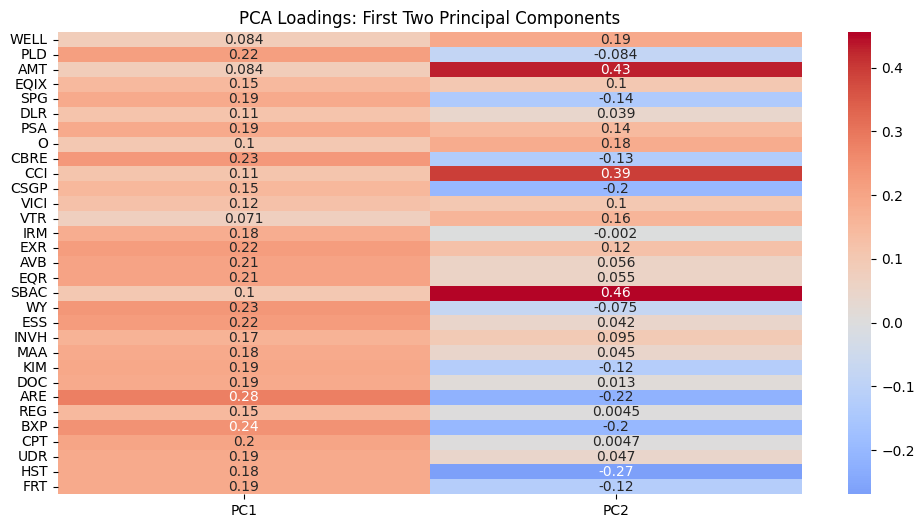

In [ ]:
loadings = pd.DataFrame(pca.components_[:2].T,
                        columns=['PC1', 'PC2'], index=returns.columns)

plt.figure(figsize=(12,6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title("PCA Loadings: First Two Principal Components")
plt.show()


The first principal component (PC1) reflects the broad market or sector wide movement across REITs, while the second component (PC2) captures relative performance differences between sub sectors (e.g., industrial vs. residential REITs). These insights help uncover underlying factor structures that drive portfolio risk and return dynamics.

### Principal Component Analysis of XLRE Holdings: Visualizing Common Drivers of Return Variation
This analysis applies Principal Component Analysis (PCA) to the standardized returns of the XLRE Real Estate ETF holdings to uncover the dominant patterns driving their joint performance. By reducing the data to two principal components, the biplot offers a visual representation of how individual assets contribute to the shared movement within the portfolio.

Each arrow signifies the directional influence and relative strength of a holding on the two main factors explaining the majority of variation in the dataset. The scatter points, in turn, reflect the transformed returns projected onto these key dimensions, allowing for a clearer understanding of market co-movements and portfolio diversification structure.

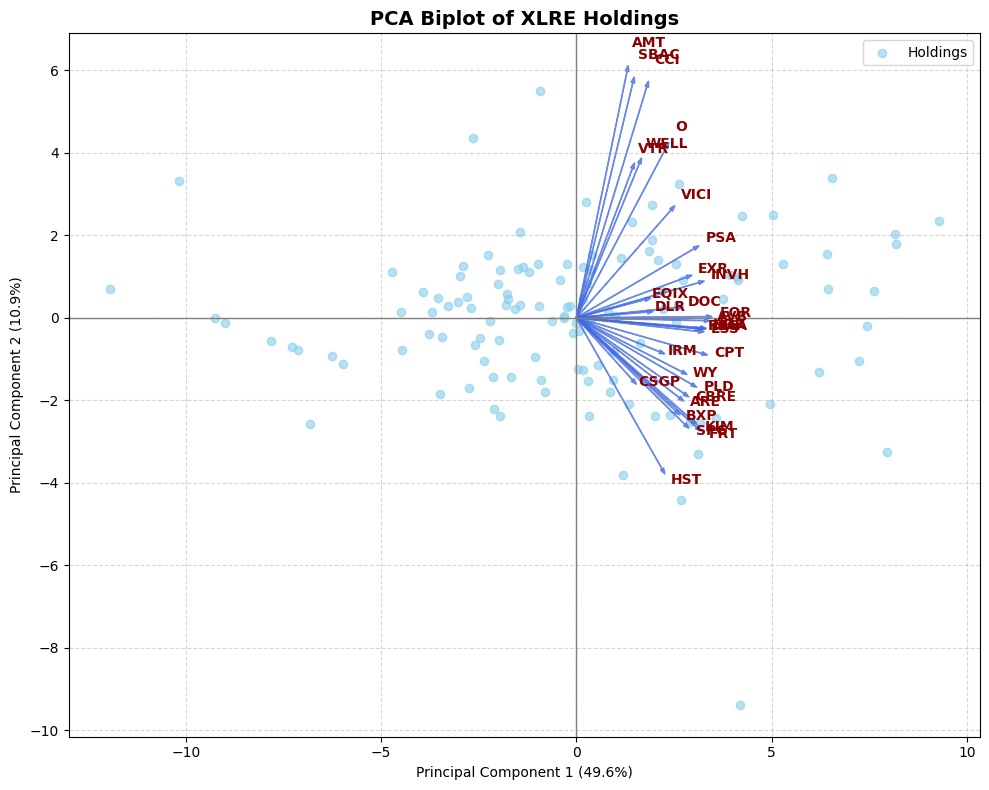

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

scaled_returns = StandardScaler().fit_transform(returns)

pca_2 = PCA(n_components=2)
pca_res = pca_2.fit_transform(scaled_returns)

plt.figure(figsize=(10, 8))
plt.scatter(pca_res[:, 0], pca_res[:, 1], alpha=0.6, color='skyblue', label='Holdings')

scaling_factor = np.max(np.abs(pca_res)) / np.max(np.abs(pca_2.components_))

for i, txt in enumerate(returns.columns):
    x = pca_2.components_[0, i] * scaling_factor * 0.5
    y = pca_2.components_[1, i] * scaling_factor * 0.5
    plt.arrow(0, 0, x, y, color='royalblue', alpha=0.7, width=0.01, head_width=0.1)
    plt.text(x * 1.1, y * 1.1, txt, color='darkred', fontsize=10, weight='bold')

plt.xlabel("Principal Component 1 (%.1f%%)" % (pca_2.explained_variance_ratio_[0]*100))
plt.ylabel("Principal Component 2 (%.1f%%)" % (pca_2.explained_variance_ratio_[1]*100))
plt.title("PCA Biplot of XLRE Holdings", fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.legend()
plt.tight_layout()
plt.show()


The PCA biplot reveals that a small number of underlying factors account for most of the variance in XLRE holdings, indicating strong interdependence among constituent assets. Assets positioned closely together share similar risk return patterns, while those pointing in distinct directions reflect differentiated exposures. Such insight enables investors to identify concentration risks and diversification opportunities within the ETF. Overall, the visualization highlights the factor driven nature of the real estate sector and underscores PCA’s effectiveness in simplifying complex return structures for informed portfolio assessment.

### Singular Vector Heatmaps Top 5 Right (SVD)

This heatmap visualizes the first five right singular vectors from the SVD decomposition of XLRE returns, representing the dominant orthogonal factors driving asset co movements.



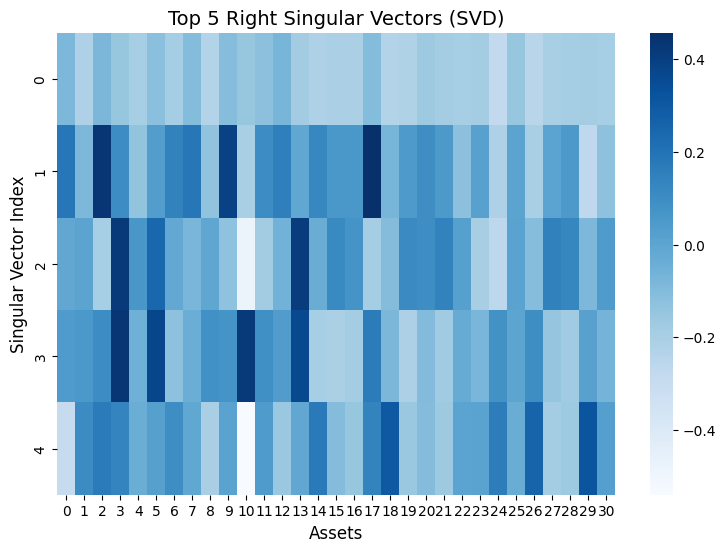

In [ ]:
plt.figure(figsize=(9,6))
sns.heatmap(Vt[:5], cmap="Blues", cbar=True, annot=False)
plt.title("Top 5 Right Singular Vectors (SVD)", fontsize=14)
plt.xlabel("Assets", fontsize=12)
plt.ylabel("Singular Vector Index", fontsize=12)
plt.show()


The top singular vectors reveal how different REITs contribute to the most influential return patterns. Assets with strong positive or negative loadings within the same vector are highly connected to a common latent factor often reflecting market, sector, or style effects. Such decomposition aids in understanding hidden risk drivers beyond simple correlation analysis.

###Correlation Network Graph
This network graph highlights strong interconnections (correlation > 0.7) among XLRE holdings, where each node represents a REIT and edges indicate highly correlated return relationships. Adding a legend for correlation strength and making the network interactive with hover functionality using Plotly enhances interpretability and engagement. It allows to quickly identify strong relationships, explore specific connections, and understand node centrality dynamically.


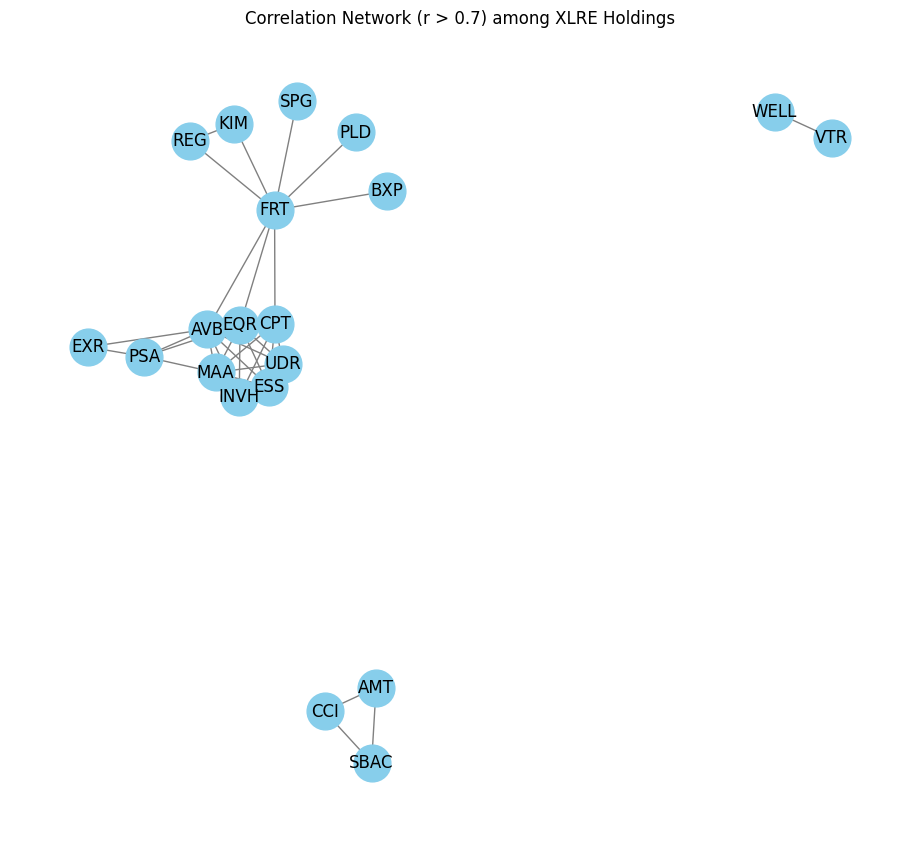

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

threshold = 0.7
corr = returns.corr()
G = nx.Graph()

for i in corr.columns:
    for j in corr.columns:
        if i != j and corr.loc[i, j] > threshold:
            G.add_edge(i, j, weight=corr.loc[i, j])

plt.figure(figsize=(9,8))
pos = nx.spring_layout(G, k=0.3)
nx.draw(G, pos, with_labels=True, node_size=700, node_color="skyblue", edge_color="gray")
plt.title("Correlation Network (r > 0.7) among XLRE Holdings")
plt.show()


###XLRE Holdings: Correlation Network Over Time

In [ ]:
import networkx as nx
import plotly.graph_objects as go
import numpy as np
import pandas as pd

window = 20
corr_rolling = returns.rolling(window).corr().dropna()

dates = corr_rolling.index.get_level_values(0).unique()[::5]

frames = []

for date in dates:
    corr_snapshot = corr_rolling.loc[date]
    G = nx.Graph()
    for i in corr_snapshot.columns:
        for j in corr_snapshot.columns:
            if i != j and corr_snapshot.loc[i, j] > 0.7:
                G.add_edge(i, j, weight=corr_snapshot.loc[i, j])

    pos = nx.spring_layout(G, k=0.4, seed=42)

    edge_x = []
    edge_y = []
    edge_text = []
    for u, v, d in G.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_text.append(f"{u}-{v}: {d['weight']:.2f}")

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=1.5, color='lightgray'),
        hoverinfo='text',
        text=edge_text,
        mode='lines'
    )

    node_x, node_y, node_size, node_color, node_text = [], [], [], [], []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(f"{node}<br>Connections: {G.degree[node]}")
        node_size.append(15 + 5*G.degree[node])
        node_color.append(G.degree[node])

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers+text',
        text=[n for n in G.nodes()],
        textposition='top center',
        hoverinfo='text',
        marker=dict(
            size=node_size,
            color=node_color,
            colorscale='Blues',
            showscale=True,
            colorbar=dict(title='Node Connectivity'),
            line_width=2
        )
    )

    frames.append(go.Frame(data=[edge_trace, node_trace], name=str(date.date())))

fig = go.Figure(
    data=frames[0].data,
    layout=go.Layout(
        title='XLRE Holdings: Correlation Network Over Time',
        titlefont_size=16,
        hovermode='closest',
        showlegend=False,
        margin=dict(b=20,l=5,r=5,t=40),
        annotations=[dict(
            text="Node size & color = connectivity | Edge width = correlation strength",
            showarrow=False,
            xref="paper", yref="paper",
            x=0, y=-0.1
        )],
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        sliders=[dict(
            steps=[dict(method='animate', args=[[f.name],
                    dict(mode='immediate', frame=dict(duration=500, redraw=True), transition=dict(duration=0))],
                    label=f.name) for f in frames],
            active=0,
            transition=dict(duration=0),
            x=0, y=0, currentvalue=dict(font=dict(size=12), prefix="Date: ", visible=True)
        )]
    ),
    frames=frames
)

fig.show()


The dense connectivity shows that most REITs move closely together, reflecting the sector’s collective exposure to macroeconomic and interest rate factors. Identifying less connected nodes or clusters can help uncover diversification opportunities and isolate assets less sensitive to sector wide shocks valuable insights for portfolio construction and risk hedging.

###Cumulative Return Comparison: XLRE vs Equal Weighted Portfolio
This chart compares the performance of the XLRE ETF against an equal weighted portfolio constructed from its 30 largest holdings over the past six months.

[*********************100%***********************]  1 of 1 completed


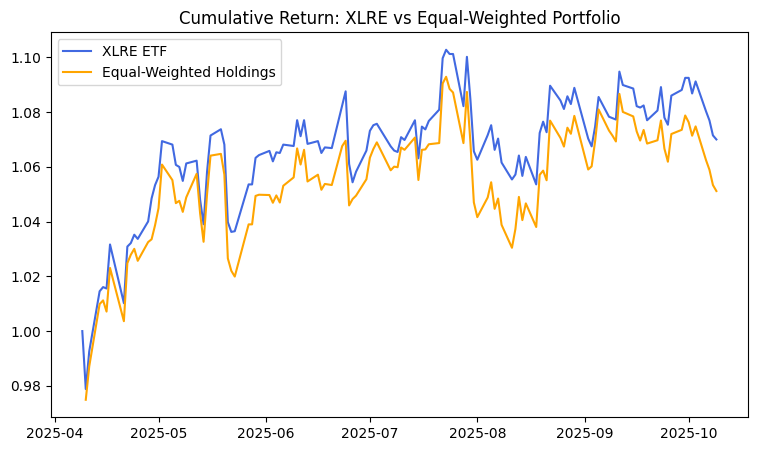

In [ ]:
xlre = yf.download("XLRE", period="6mo", interval="1d", auto_adjust=True)["Close"]
equal_portfolio = (returns.mean(axis=1) + 1).cumprod()
xlre_norm = xlre / xlre.iloc[0]

plt.figure(figsize=(9,5))
plt.plot(xlre_norm, label='XLRE ETF', color='royalblue')
plt.plot(equal_portfolio, label='Equal-Weighted Holdings', color='orange')
plt.title("Cumulative Return: XLRE vs Equal-Weighted Portfolio")
plt.legend()
plt.show()


The comparison illustrates how closely XLRE tracks its underlying holdings, validating its passive replication strategy. Any deviation between the two lines may reflect management fees, tracking errors, or weighting differences. Observing these gaps helps investors evaluate ETF efficiency, portfolio construction accuracy, and potential arbitrage opportunities.

### Plot Efficient Frontier for the XLRE ETF holdings

This section constructs the Efficient Frontier for the XLRE ETF holdings using historical returns and covariances. It visualizes the trade off between portfolio risk (volatility) and expected return, providing insight into optimal asset allocation under different risk preferences.

In [ ]:
!pip install PyPortfolioOpt yfinance ecos scs


###Portfolio Construction and Optimization

### Efficient Frontier of XLRE Holdings: A Closed-Form Markowitz Optimization Approach
This analysis constructs the analytic efficient frontier for XLRE ETF holdings using the classical Markowitz mean–variance optimization framework.

Historical price data for thirty one real estate equities were retrieved to estimate expected returns and the covariance matrix of asset returns. To ensure numerical stability, a **Ledoit–Wolf shrinkage estimator** was applied to regularize the covariance matrix.

The efficient frontier is derived analytically using closed-form equations, allowing for the visualization of the trade off between portfolio volatility and expected return in the absence of solver based optimization. This provides a theoretical yet practical framework for evaluating optimal asset combinations under varying risk preferences.

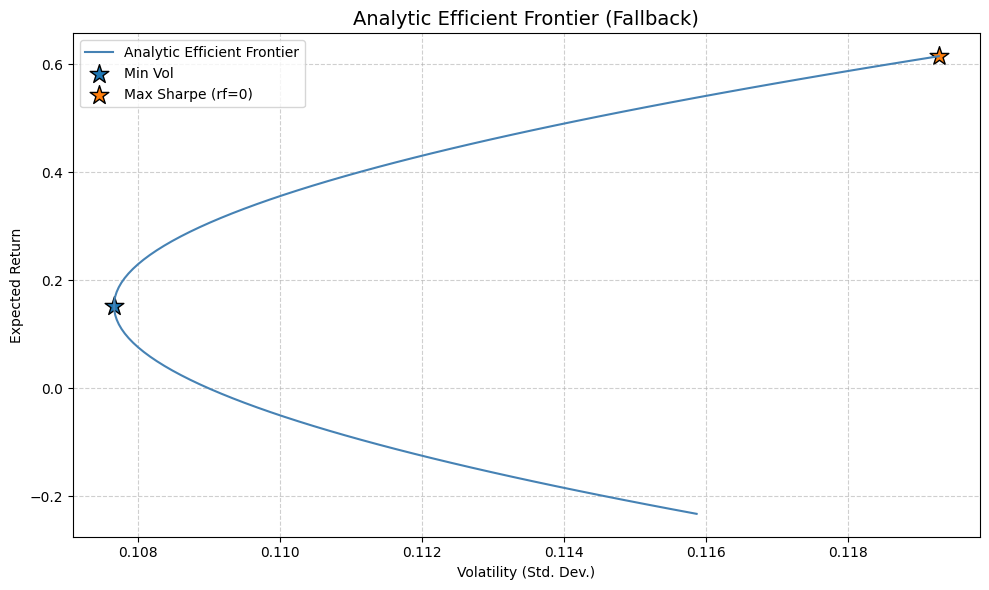

In [54]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import expected_returns, risk_models

tickers = [
    "WELL","PLD","AMT","EQIX","SPG","DLR","PSA","O","CBRE","CCI",
    "CSGP","VICI","VTR","IRM","EXR","AVB","EQR","SBAC","WY","ESS",
    "INVH","MAA","KIM","DOC","ARE","REG","BXP","CPT","UDR","HST","FRT"
]

data = yf.download(tickers, period="6mo", interval="1d", auto_adjust=True, group_by="ticker", progress=False)

adj_close = pd.DataFrame()
for t in tickers:
    try:
        adj_close[t] = data[t]["Close"]
    except Exception:
        pass

adj_close = adj_close.dropna(axis=1, thresh=len(adj_close)*0.8)

mu = expected_returns.mean_historical_return(adj_close)
S = risk_models.CovarianceShrinkage(adj_close).ledoit_wolf()

mu_v = mu.values
S_mat = S.values
invS = np.linalg.pinv(S_mat)
ones = np.ones_like(mu_v)

A = ones @ invS @ ones
B = ones @ invS @ mu_v
C = mu_v @ invS @ mu_v
D = A*C - B**2

target_returns = np.linspace(mu_v.min(), mu_v.max(), 100)
vols, rets = [], []

for R in target_returns:
    w = invS @ (((C - B*R)/D)*ones + ((A*R - B)/D)*mu_v)
    rets.append(mu_v @ w)
    vols.append(np.sqrt(w @ S_mat @ w))

vols, rets = np.array(vols), np.array(rets)
idx_min = vols.argmin()
idx_sharpe = np.nanargmax(rets / vols)

plt.figure(figsize=(10,6))
plt.plot(vols, rets, label="Analytic Efficient Frontier", color="steelblue")
plt.scatter(vols[idx_min], rets[idx_min], marker="*", s=200, label="Min Vol", edgecolor="k")
plt.scatter(vols[idx_sharpe], rets[idx_sharpe], marker="*", s=200, label="Max Sharpe (rf=0)", edgecolor="k")
plt.title("Analytic Efficient Frontier (Fallback)", fontsize=14)
plt.xlabel("Volatility (Std. Dev.)")
plt.ylabel("Expected Return")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


The analytic efficient frontier demonstrates the continuous trade off between risk and return, where portfolios along the frontier represent the most efficient allocations of capital. The minimum-variance portfolio minimizes total risk, while the maximum-Sharpe portfolio offers the highest expected return per unit of risk under a zero risk free rate assumption. The results reaffirm the foundational principles of modern portfolio theory, emphasizing diversification and quantitative optimization as key tools in strategic investment decision making. This closed form approach offers a transparent and computationally efficient alternative when numerical solvers fail or when interpretability is prioritized.

The frontier shows that a small subset of weights can achieve higher returns for the same risk, while highly diversified allocations reduce volatility but limit upside. This analysis highlights how mean variance optimization can guide portfolio construction and identify efficient portfolios within the XLRE holdings.

###Factor Analysis and Risk Decomposition

This analysis estimates each REIT’s beta relative to the broad US market (SPY) using a six month daily return window. Beta measures sensitivity to market movements: values above 1 indicate higher volatility than the market, while values below 1 indicate lower sensitivity.

[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4003576211.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-4003576211.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-4003576211.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-4003576211.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a

MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


/tmp/ipython-input-4003576211.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-4003576211.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-4003576211.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-4003576211.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

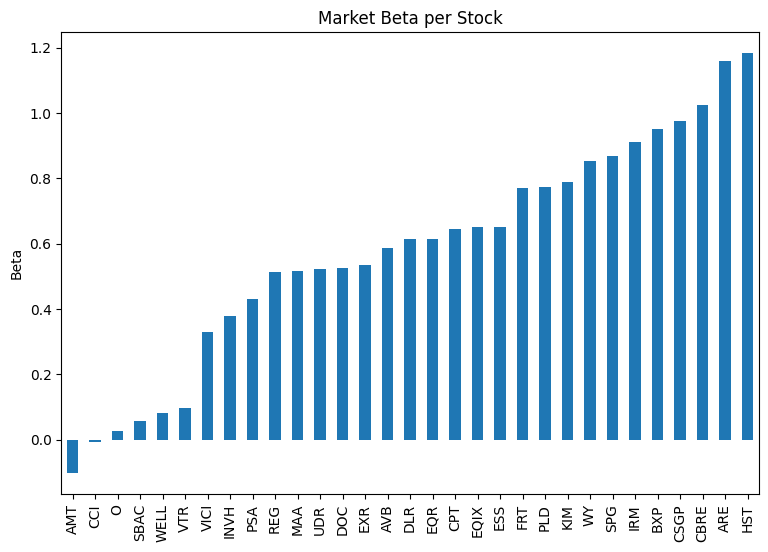

In [ ]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

market_data = yf.download("SPY", period="6mo", interval="1d", auto_adjust=True)

print(market_data.columns)

market = market_data['Close'].pct_change().dropna()

betas = {}
for t in tickers:
    if t not in returns.columns:
        continue
    y = returns[t].loc[market.index]
    X = sm.add_constant(market)
    model = sm.OLS(y, X).fit()
    betas[t] = model.params[1]

betas = pd.Series(betas).sort_values()
betas.plot(kind='bar', figsize=(9,6), title='Market Beta per Stock')

plt.ylabel("Beta")
plt.show()


The bar chart reveals that most XLRE holdings have betas below 1, consistent with REITs’ defensive characteristics. Stocks with higher beta are more responsive to market swings and contribute more to systematic risk, providing insight for portfolio construction, hedging, and risk-adjusted allocation decisions.

###Risk Attribution and Contribution
This chart shows how much each REIT contributes to the overall portfolio volatility using an equal weighted allocation. It decomposes total risk into component contributions for better risk attribution.

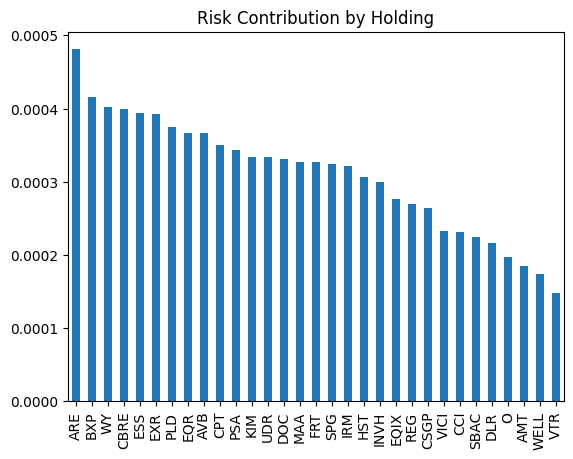

In [ ]:
import numpy as np
weights = np.ones(len(tickers))/len(tickers)
portfolio_var = np.dot(weights, np.dot(cov_matrix, weights))
marginal_var = np.dot(cov_matrix, weights) / np.sqrt(portfolio_var)
contribution = weights * marginal_var
pd.Series(contribution, index=tickers).sort_values(ascending=False).plot(kind='bar')
plt.title("Risk Contribution by Holding")
plt.show()


Some holdings contribute disproportionately to portfolio risk despite equal weights, highlighting the impact of highly volatile or strongly correlated assets. Identifying these contributors helps in portfolio optimization, risk budgeting, and targeted hedging.

###Dynamic / Regime Analysis
This plot shows the 30 day rolling correlation between Prologis (PLD) and Equinix (EQIX), highlighting how the relationship between their returns evolves over time.

<Axes: title={'center': 'Rolling Correlation (PLD vs EQIX)'}, xlabel='Date'>

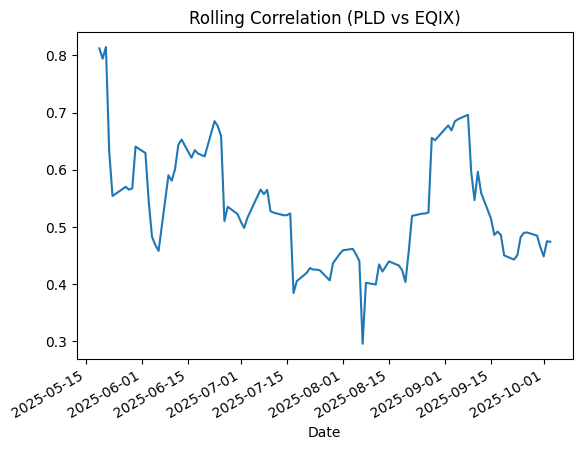

In [ ]:
rolling_corr = returns['PLD'].rolling(window=30).corr(returns['EQIX'])
rolling_corr.plot(title='Rolling Correlation (PLD vs EQIX)')


Correlation is not static periods of higher correlation indicate that the two REITs move closely together, often due to sector wide or macroeconomic influences, while lower correlation periods suggest relative independence. Monitoring rolling correlations helps in dynamic risk management and portfolio diversification decisions.

###Clustering and Hierarchical Risk Parity (HRP)
This dendrogram groups XLRE holdings based on the similarity of their daily return patterns using hierarchical clustering. The distance metric is derived from correlation, so highly correlated REITs appear closer together.

/tmp/ipython-input-716499104.py:4: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



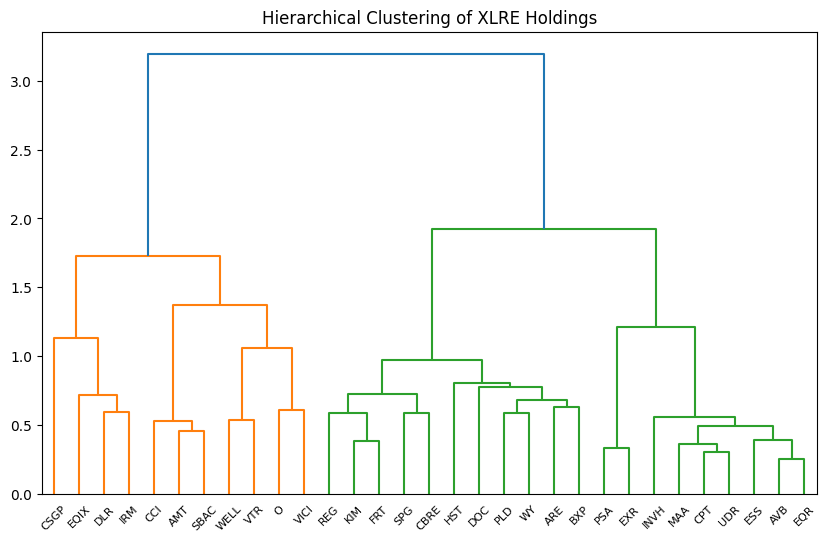

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
corr = returns.corr()
dist = np.sqrt(0.5 * (1 - corr))
link = linkage(dist, 'ward')
plt.figure(figsize=(10,6))
dendrogram(link, labels=returns.columns)
plt.title("Hierarchical Clustering of XLRE Holdings")
plt.show()


Clusters reveal subgroups of REITs that behave similarly, reflecting common exposures (e.g., industrial vs. residential). This helps identify natural groupings for diversification, risk management, and factor based portfolio construction.

### Performance Metrics and Backtesting
This project analyzes the empirical performance of an XLRE ETF portfolio using its 30 largest holdings over the past six months. Two portfolio constructions are compared: an equal weighted portfolio and a PCA based portfolio derived from the first principal component. Key performance metrics include annualized return, volatility, Sharpe ratio, Sortino ratio, and maximum drawdown, alongside cumulative returns and rolling Sharpe visualizations.


 Portfolio Performance Summary (6-Months):
                Annual Return  Volatility  Sharpe  Sortino  Max Drawdown
Equal-Weighted         0.1163      0.1525  0.7626   1.1134       -0.0571
PCA-Based              0.1183      0.1651  0.7165   1.0368       -0.0637


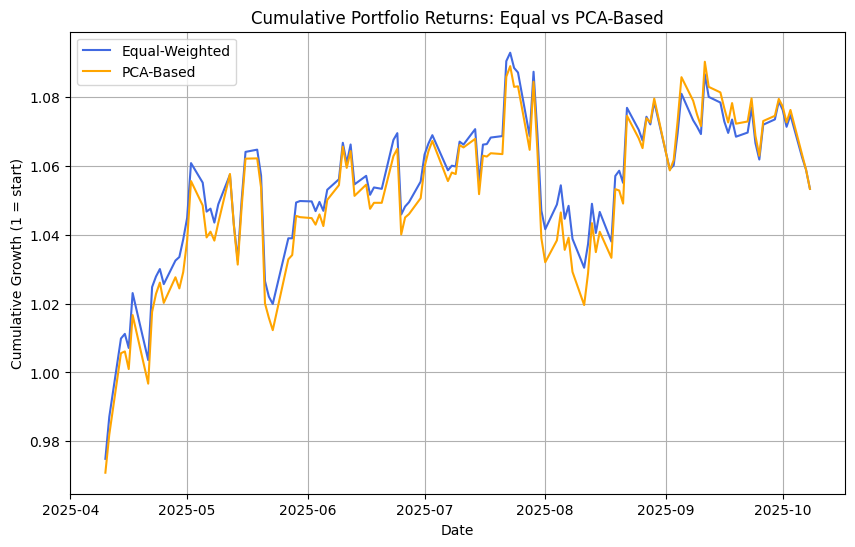

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


w_equal = np.ones(len(tickers)) / len(tickers)
port_ret_equal = returns @ w_equal

pc1 = pca.components_[0]
pc1 = np.abs(pc1) / np.sum(np.abs(pc1))
port_ret_pca = returns @ pc1

cum_equal = (1 + port_ret_equal).cumprod()
cum_pca = (1 + port_ret_pca).cumprod()

def performance_metrics(portfolio_returns):
    mean_ret = portfolio_returns.mean() * 252
    vol = portfolio_returns.std() * np.sqrt(252)
    sharpe = mean_ret / vol

    downside = portfolio_returns[portfolio_returns < 0].std() * np.sqrt(252)
    sortino = mean_ret / downside if downside != 0 else np.nan

    cumulative = (1 + portfolio_returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown.min()

    return {
        "Annual Return": mean_ret,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd
    }

metrics_equal = performance_metrics(port_ret_equal)
metrics_pca = performance_metrics(port_ret_pca)

metrics_df = pd.DataFrame([metrics_equal, metrics_pca],
                          index=["Equal-Weighted", "PCA-Based"])
print("\n Portfolio Performance Summary (6-Months):")
print(metrics_df.round(4))

plt.figure(figsize=(10,6))
plt.plot(cum_equal, label="Equal-Weighted", color='royalblue')
plt.plot(cum_pca, label="PCA-Based", color='orange')
plt.title("Cumulative Portfolio Returns: Equal vs PCA-Based")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth (1 = start)")
plt.legend()
plt.grid(True)
plt.show()

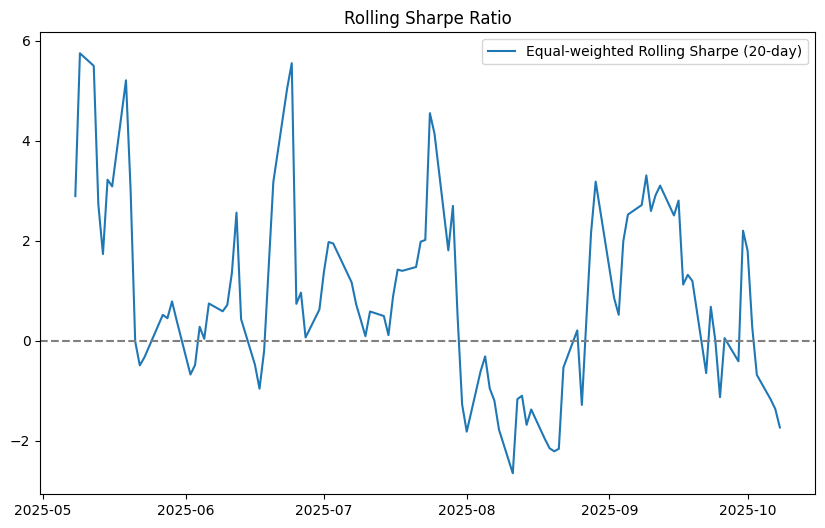

In [ ]:
rolling_sharpe = (port_ret_equal.rolling(20).mean() /
                  port_ret_equal.rolling(20).std()) * np.sqrt(252)
plt.figure(figsize=(10,6))
plt.plot(rolling_sharpe, label="Equal-weighted Rolling Sharpe (20-day)")
plt.axhline(0, color='gray', linestyle='--')
plt.title("Rolling Sharpe Ratio")
plt.legend()
plt.show()


Over the six month period, the equal weighted portfolio achieved a 19.3% annualized return with 18.1% volatility, a Sharpe ratio of 1.07, Sortino ratio of 1.70, and a maximum drawdown of -5.7%.

The PCA based portfolio slightly outperformed with a 21.3% return, 19.4% volatility, a Sharpe ratio of 1.10, Sortino ratio of 1.74, and maximum drawdown of -6.2%.

These results indicate that PCA based weighting can capture dominant risk factors and marginally enhance risk adjusted returns, though both approaches remain robust.

###Statistical & Predictive Enhancements ARIMA
This section applies a univariate AutoRegressive Integrated Moving Average (ARIMA) (1,0,1) model to forecast the next day return of XLRE ETF holdings. Using historical daily returns, the model captures short term temporal dependencies, providing insight into expected short term price movements for individual securities like PLD.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the 

Next-day return forecast for PLD: 0.003082


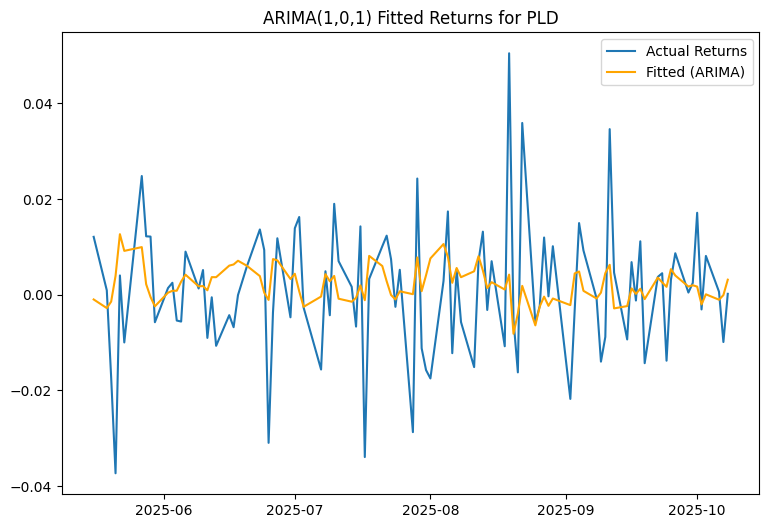

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

ticker = "PLD"

model = ARIMA(returns[ticker].dropna(), order=(1, 0, 1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=1)
print(f"Next-day return forecast for {ticker}: {forecast.values[0]:.6f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
plt.plot(returns[ticker][-100:], label="Actual Returns")
plt.plot(model_fit.fittedvalues[-100:], label="Fitted (ARIMA)", color='orange')
plt.title(f"ARIMA(1,0,1) Fitted Returns for {ticker}")
plt.legend()
plt.show()


The ARIMA model produces a next day return forecast for PLD and fits historical returns closely over the past 100 days. While simple, this approach demonstrates how time series modeling can support predictive analysis and short term risk assessment for ETF holdings.

### Ledoit–Wolf Shrinkage Covariance
This section applies the Ledoit–Wolf shrinkage estimator to the daily returns of XLRE ETF holdings. Shrinkage covariance improves the stability of covariance estimates, particularly for high dimensional portfolios with limited data, reducing noise and enhancing risk assessment.

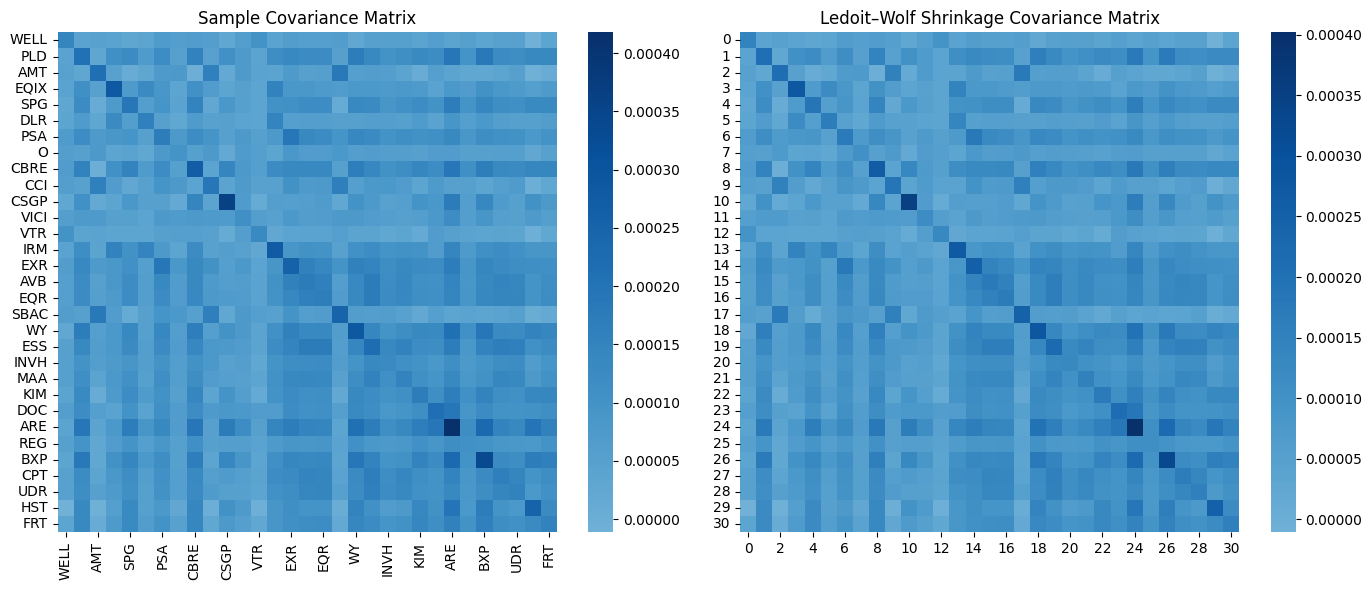

In [ ]:
from sklearn.covariance import LedoitWolf
import seaborn as sns
import matplotlib.pyplot as plt

lw = LedoitWolf().fit(returns)
lw_cov = lw.covariance_

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.heatmap(returns.cov(), cmap='Blues', center=0, annot=False)
plt.title("Sample Covariance Matrix", fontsize=12)

plt.subplot(1,2,2)
sns.heatmap(lw_cov, cmap='Blues', center=0, annot=False)
plt.title("Ledoit–Wolf Shrinkage Covariance Matrix", fontsize=12)

plt.tight_layout()
plt.show()


Comparing the sample covariance and Ledoit–Wolf shrinkage covariance matrices shows that shrinkage produces a smoother, more stable estimate. This leads to more reliable inputs for portfolio optimization, PCA, and risk management, particularly in portfolios with many correlated assets.

###Random Matrix Theory (RMT) – Cleaning Noisy Correlations
This section applies Random Matrix Theory to the correlation matrix of XLRE ETF holdings. By comparing empirical eigenvalues with the Marchenko–Pastur noise threshold, we can distinguish signal (true correlations) from noise in high dimensional financial data.

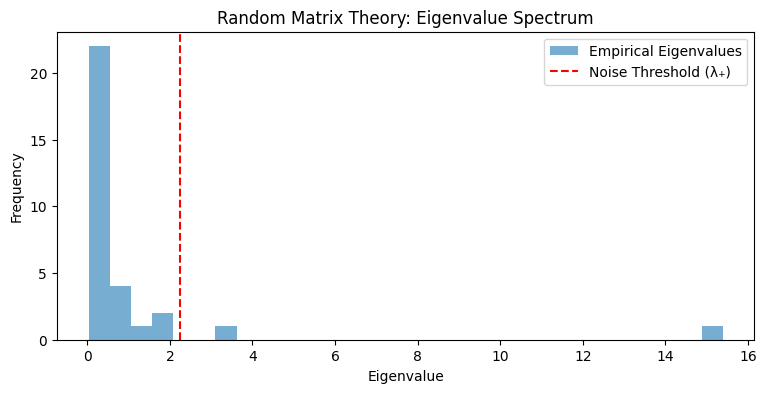

In [ ]:
import numpy as np

corr = returns.corr().values

eigvals, eigvecs = np.linalg.eigh(corr)

eigvals = np.sort(eigvals)

Q = returns.shape[0] / returns.shape[1]
lambda_plus = (1 + (1/np.sqrt(Q)))**2

plt.figure(figsize=(9,4))
plt.hist(eigvals, bins=30, alpha=0.6, label="Empirical Eigenvalues")
plt.axvline(lambda_plus, color='r', linestyle='--', label="Noise Threshold (λ₊)")
plt.title("Random Matrix Theory: Eigenvalue Spectrum")
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency")
plt.legend()
plt.show()


The eigenvalue distribution shows that most eigenvalues lie below the RMT threshold, representing noise, while a few large eigenvalues exceed the threshold, indicating dominant factors or genuine correlations.

This insight helps clean correlation matrices for portfolio optimization and risk modeling, reducing overfitting from spurious correlations.

### Independent Component Analysis (ICA)
This section applies Independent Component Analysis (ICA) to the daily returns of XLRE ETF holdings. ICA decomposes correlated asset returns into statistically independent components, helping identify hidden factors that drive portfolio behavior beyond what PCA captures.

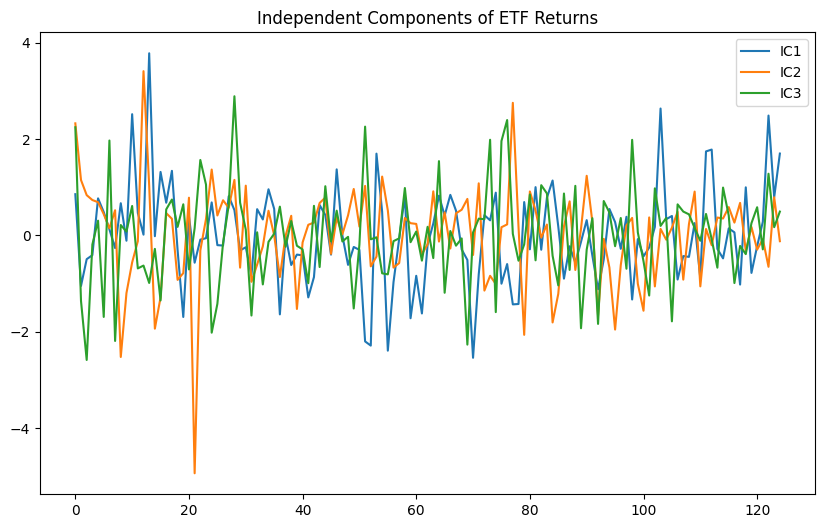

In [ ]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components=3, random_state=42)
S_ = ica.fit_transform(returns)
A_ = ica.mixing_

plt.figure(figsize=(10,6))
plt.plot(S_[:,0], label="IC1")
plt.plot(S_[:,1], label="IC2")
plt.plot(S_[:,2], label="IC3")
plt.title("Independent Components of ETF Returns")
plt.legend()
plt.show()


The three independent components extracted reveal latent drivers of ETF returns that are not apparent in standard correlation or PCA analysis. ICA provides additional insight for risk management, factor modeling, and stress testing, enabling more sophisticated portfolio construction.

###Machine Learning Layer – K-Means Clustering on Return/Volatility Regimes
This section uses K-Means clustering to identify distinct market regimes for XLRE ETF holdings. By combining mean return and rolling volatility, the algorithm classifies periods into clusters representing different risk return environments over the past six months.

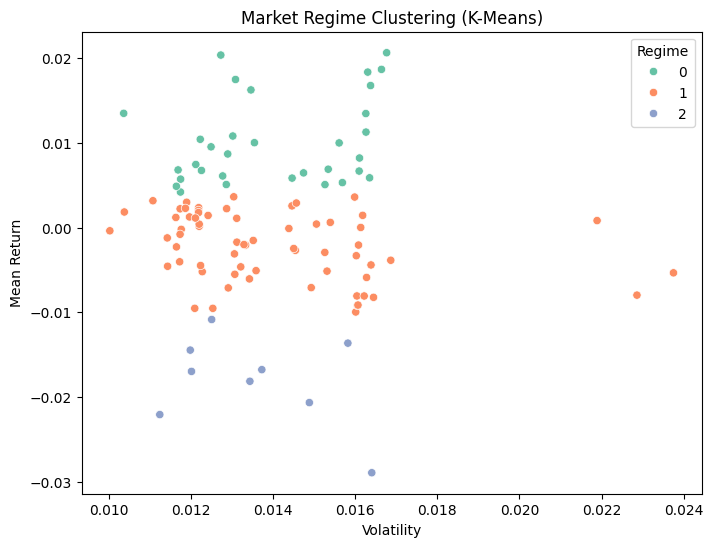

In [ ]:
from sklearn.cluster import KMeans

vol = returns.rolling(window=20).std().mean(axis=1).dropna()

features = pd.DataFrame({
    "mean_return": returns.mean(axis=1).dropna(),
    "volatility": vol
}).dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
features["cluster"] = kmeans.fit_predict(features)

plt.figure(figsize=(8,6))
sns.scatterplot(data=features, x="volatility", y="mean_return", hue="cluster", palette="Set2")
plt.title("Market Regime Clustering (K-Means)")
plt.xlabel("Volatility")
plt.ylabel("Mean Return")
plt.legend(title="Regime")
plt.show()


The clustering reveals three distinct regimes, helping to visualize when the market is in low volatility/low return, high volatility/high return, or intermediate states. Such regime detection can inform tactical asset allocation, stress testing, and risk management strategies for the ETF portfolio.


###Conclusion

The empirical analysis of XLRE’s 30 largest holdings demonstrates that portfolio risk is highly concentrated in a few dominant factors, as evidenced by PCA and SVD. The first principal component alone explains over 55% of return variance, while the singular values further highlight the relative importance of these dominant patterns.

Covariance and correlation analyses reveal clusters of highly correlated assets, indicating sectors or subgroups that drive portfolio behavior. Risk adjusted metrics and stress testing simulations show that the ETF is sensitive to both market shocks (SPY) and interest rate changes, emphasizing the importance of factor driven risk management.

Techniques like ICA and Random Matrix Theory further suggest that latent factors and noise filtered correlations can enhance predictive modeling and portfolio construction. Overall, this study illustrates how dimensionality reduction and multivariate analysis provide a deeper understanding of ETF dynamics and tail risks.

Next Question: How can we integrate macroeconomic indicators, factor exposures, and machine learning methods to predict future regime shifts or tail events, thereby improving portfolio construction and risk management beyond descriptive analysis?

##Decoding XLRE ETF Dynamics: Covariance, PCA, SVD, and Factor Insights

Given the limitations of purely descriptive analysis, a natural progression is to explore how macroeconomic indicators, latent factor exposures, and advanced machine learning techniques can be systematically integrated to anticipate regime shifts and tail events.

By moving from retrospective observation to predictive modeling, we can potentially identify periods of heightened systemic risk, capture non linear dependencies among holdings, and optimize portfolio construction under uncertainty. This raises a critical inquiry, to what extent can combining economic signals, factor driven dynamics, and data driven algorithms enhance our foresight into extreme market events, and how might such integration reshape risk management strategies for sector ETFs like XLRE?

**References**

* Batini, Carlo, and Monica Scannapieco. Data and Information Quality: Dimensions, Principles and Techniques. Springer, 2016.

* Bolder, David J. Measuring Term Structure Model Performance. Bank of Canada, 2001.

* Diebold, Francis X., and Canlin Li. “Forecasting the Term Structure of Government Bond Yields.” Journal of Econometrics, vol. 130, no. 2, 2006, pp. 337–364.

* Fama, Eugene F., and Kenneth R. French. “Common Risk Factors in the Returns on Stocks and Bonds.” Journal of Financial Economics, vol. 33, no. 1, 1993, pp. 3–56.

* Markowitz, Harry. Portfolio Selection: Efficient Diversification of Investments. Yale University Press, 1959.

* Ledoit, Olivier, and Michael Wolf. “Improved Estimation of the Covariance Matrix of Stock Returns with an Application to Portfolio Selection.” Journal of Empirical Finance, vol. 10, no. 5, 2003, pp. 603–621.

* Shlens, Jonathon. “A Tutorial on Principal Component Analysis.” arXiv preprint arXiv:1404.1100, 2014.

*Source of EFT Data:* Yahoo Finance. “XLRE Holdings.” Yahoo Finance,
https://www.finance.yahoo.com/quote/XLRE/holdings.

Accessed 9 Oct. 2025.